# Predictive modeling of customer bookings

**In this Jupyternotebook, we will focus on Data Wrangling & Exploratory Data Analysis (EDA).**

---

### Data Wrangling

First, we must explore the data in order to better understand what we have and the statistical properties of the dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../Raw_Data/customer_booking.csv", encoding="ISO-8859-1")
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


The `.head()` method allows us to view the first 5 rows in the dataset, this is useful for visual inspection of our columns

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

The `.info()` method gives us a data description, telling us the names of the columns, their data types and how many null values we have. Fortunately, we have no null values. It looks like some of these columns should be converted into different data types, e.g. flight_day.

To provide more context, below is a more detailed data description, explaining exactly what each column means:

- `num_passengers` = number of passengers travelling
- `sales_channel` = sales channel booking was made on
- `trip_type` = trip Type (Round Trip, One Way, Circle Trip)
- `purchase_lead` = number of days between travel date and booking date
- `length_of_stay` = number of days spent at destination
- `flight_hour` = hour of flight departure
- `flight_day` = day of week of flight departure
- `route` = origin -> destination flight route
- `booking_origin` = country from where booking was made
- `wants_extra_baggage` = if the customer wanted extra baggage in the booking
- `wants_preferred_seat` = if the customer wanted a preferred seat in the booking
- `wants_in_flight_meals` = if the customer wanted in-flight meals in the booking
- `flight_duration` = total duration of flight (in hours)
- `booking_complete` = flag indicating if the customer completed the booking

Before we compute any statistics on the data, lets do any necessary data conversion

In [4]:
df["flight_day"].unique()

array(['Sat', 'Wed', 'Thu', 'Mon', 'Sun', 'Tue', 'Fri'], dtype=object)

In [5]:
mapping = {
    "Mon": 1,
    "Tue": 2,
    "Wed": 3,
    "Thu": 4,
    "Fri": 5,
    "Sat": 6,
    "Sun": 7,
}

df["flight_day"] = df["flight_day"].map(mapping)

This is basically converting the `flight_day` into a numerical value using the label encoding method.

In [6]:
df["flight_day"].unique()

array([6, 3, 4, 1, 7, 2, 5])

In [7]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,flight_day,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,3.814420,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,1.992792,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,1.000000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,2.000000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,4.000000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,5.000000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,7.000000,1.000000,1.000000,1.000000,9.500000,1.000000


The `.describe()` method gives us a summary of descriptive statistics over the entire dataset (only works for numeric columns). This gives us a quick overview of a few things such as the mean, min, max and overall distribution of each column.

From this point, you should continue exploring the dataset with some visualisations and other metrics that you think may be useful. Then, you should prepare your dataset for predictive modelling. Finally, you should train your machine learning model, evaluate it with performance metrics and output visualisations for the contributing variables. All of this analysis should be summarised in your single slide.

### Exploratory data analysis

      sales_channel  trip_type   route booking_origin
0          Internet  RoundTrip  AKLDEL    New Zealand
1          Internet  RoundTrip  AKLDEL    New Zealand
2          Internet  RoundTrip  AKLDEL          India
3          Internet  RoundTrip  AKLDEL    New Zealand
4          Internet  RoundTrip  AKLDEL          India
...             ...        ...     ...            ...
49995      Internet  RoundTrip  PERPNH      Australia
49996      Internet  RoundTrip  PERPNH      Australia
49997      Internet  RoundTrip  PERPNH      Australia
49998      Internet  RoundTrip  PERPNH      Australia
49999      Internet  RoundTrip  PERPNH      Australia

[50000 rows x 4 columns]


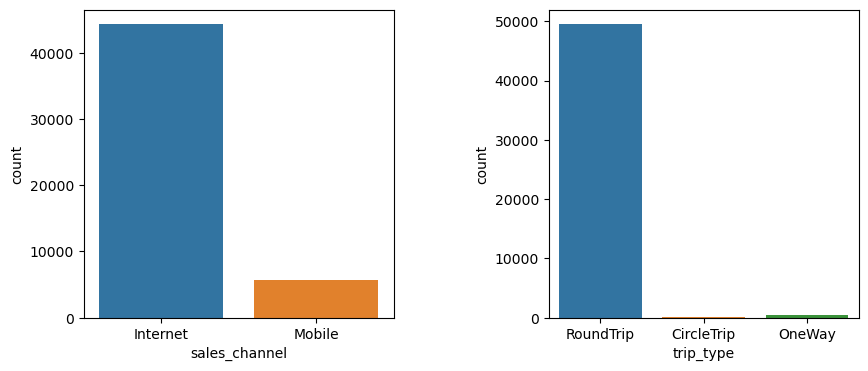

In [8]:
# Look into categorical features 
df_cat = df.select_dtypes(include = ["object"])
print(df_cat)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
sns.countplot(x="sales_channel", data=df_cat, ax=ax[0])
sns.countplot(x="trip_type", data=df_cat, ax=ax[1])
plt.subplots_adjust(wspace=0.5)
plt.show()

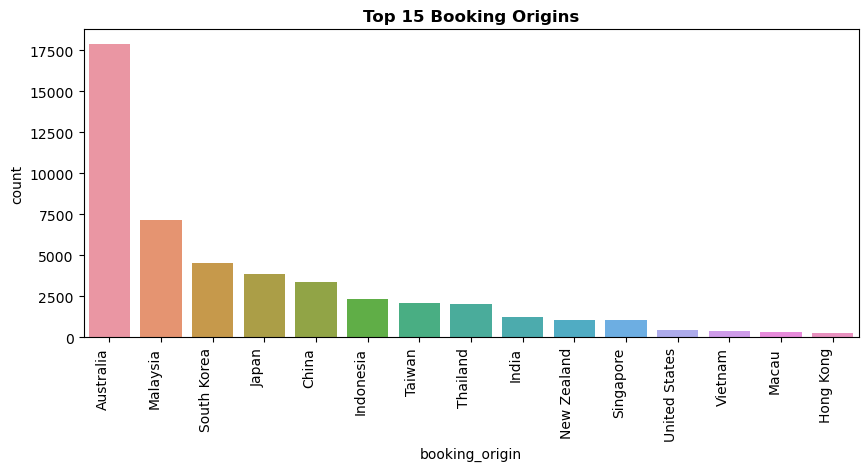

In [9]:
# Look into the top 15 booking_origin
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 4))
sns.countplot(x="booking_origin", data=df_cat, ax=ax, order=df_cat["booking_origin"].value_counts().head(15).index)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')
plt.title("Top 15 Booking Origins", fontweight="bold")
plt.show()

In [10]:
# Extract departure and arrival cities from the route column
df['departure_city'] = df['route'].str[:3]
df['arrival_city'] = df['route'].str[3:]

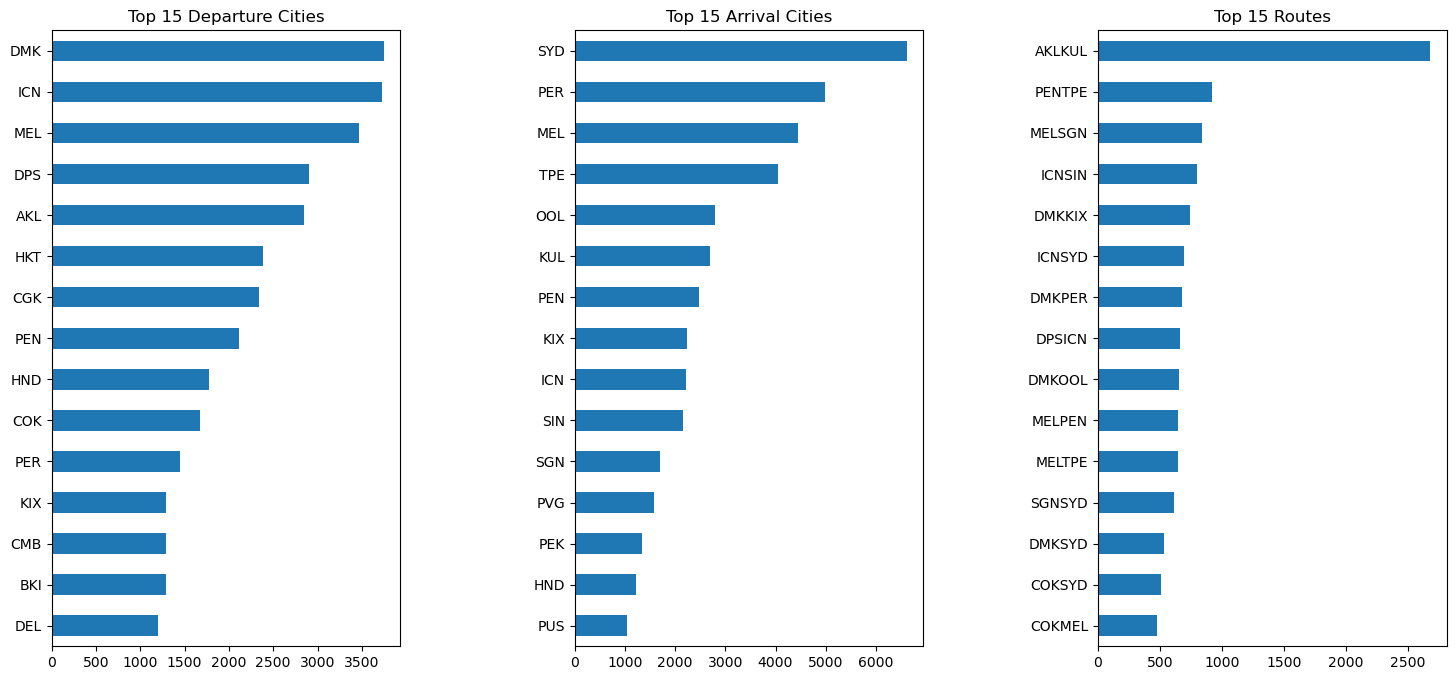

In [11]:
# Look into the top 15 departure_city, arrival_city, and route
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(18, 8))
df['departure_city'].value_counts().head(15).sort_values().plot(kind='barh', ax=ax[0], title='Top 15 Departure Cities')
df['arrival_city'].value_counts().head(15).sort_values().plot(kind='barh', ax=ax[1], title='Top 15 Arrival Cities')
df['route'].value_counts().head(15).sort_values().plot(kind='barh', ax=ax[2], title='Top 15 Routes')
plt.subplots_adjust(wspace=0.5)
plt.show()

In [12]:
# Create new features
df['add_ons_count'] = df['wants_extra_baggage'] + df['wants_preferred_seat'] + df['wants_in_flight_meals']
df['is_weekend'] = (df['flight_day'].isin([6, 7])).astype(int)
df['booking_urgency'] = (df['purchase_lead'] < df['purchase_lead'].median()).astype(int)
df['long_haul'] = (df['flight_duration'] > df['flight_duration'].median()).astype(int)
df['is_AM'] = (df['flight_hour'] < 12).astype(int)

In [13]:
import airportsdata
import pycountry
import pandas as pd

# Load IATA airport data
airports = airportsdata.load("IATA")

def code_to_country(code):
    if pd.isna(code):
        return None
    
    code = str(code).strip().upper()
    
    airport = airports.get(code)
    if airport is None:
        return None
    
    country_code = airport.get("country")
    
    country = pycountry.countries.get(alpha_2=country_code)
    if country is None:
        return country_code
    
    return country.name

# Apply the function to the departure_city and arrival_city columns
df["departure_country"] = df["departure_city"].apply(code_to_country)
df["arrival_country"] = df["arrival_city"].apply(code_to_country)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  int64  
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
 14  departure_city         50000 non-null  object 
 15  ar

In [15]:
# Check for missing values in the new country columns
print(df[df["arrival_country"].isna()]['arrival_city'].unique())
print(df[df["departure_country"].isna()]['departure_city'].unique())

['REP']
['REP']


In [16]:
# Fill missing values with "Cambodia" based on the city names
df["departure_country"] = df["departure_country"].fillna("Cambodia")
df["arrival_country"] = df["arrival_country"].fillna("Cambodia")

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  int64  
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
 14  departure_city         50000 non-null  object 
 15  ar

In [18]:
# Create a new feature to indicate if the flight is domestic or international
df['is_domestic'] = (df['departure_country'] == df['arrival_country']).astype(int)

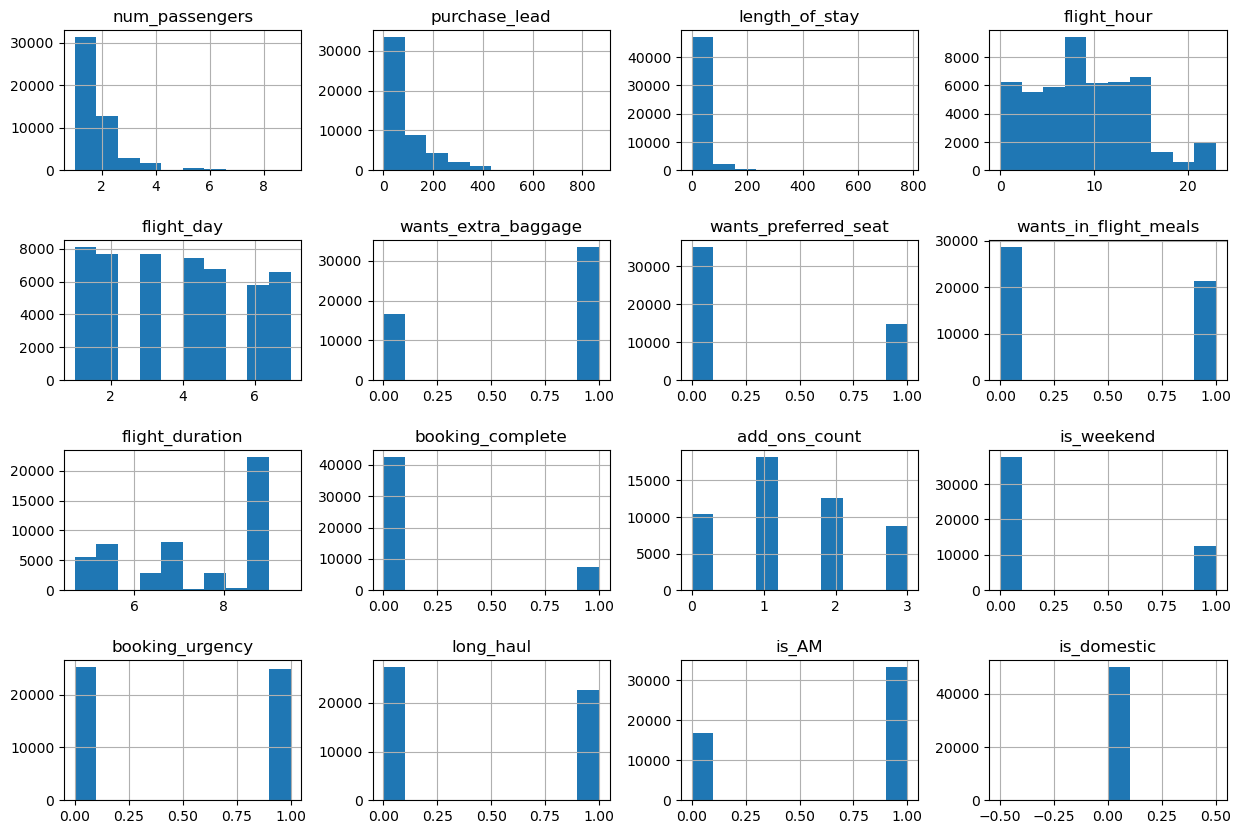

In [19]:
# Look into distributions of feature values
df.hist(figsize=(15,10))
plt.subplots_adjust(hspace=0.5)

In [20]:
# Look into the distribution of the target variable
df["booking_complete"].value_counts(normalize=True)

0    0.85044
1    0.14956
Name: booking_complete, dtype: float64

In [21]:
# Call the .corr() method on the dataset 
df.corr()

/var/folders/4s/dkhgvddx5kb346fv_thq5bqh0000gn/T/ipykernel_90908/3186774315.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()


,num_passengers,purchase_lead,length_of_stay,flight_hour,flight_day,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,add_ons_count,is_weekend,booking_urgency,long_haul,is_AM,is_domestic
num_passengers,1.000000,0.212606,-0.115850,0.015607,0.015407,0.120404,0.028544,0.022943,-0.063169,0.024116,0.080757,0.025070,-0.179844,-0.082461,-0.017272,NaN
purchase_lead,0.212606,1.000000,-0.076560,0.035973,0.036531,-0.022207,-0.004499,-0.022653,0.067866,-0.022131,-0.023624,0.086171,-0.686019,0.029696,-0.035048,NaN
length_of_stay,-0.115850,-0.076560,1.000000,-0.024872,-0.000310,0.176757,0.032264,0.098828,0.141181,-0.042408,0.146270,-0.004365,0.054073,0.195728,0.039195,NaN
flight_hour,0.015607,0.035973,-0.024872,1.000000,0.024086,-0.011434,0.012171,0.013014,-0.002101,0.007127,0.006592,0.033295,-0.035190,-0.019864,-0.799565,NaN
flight_day,0.015407,0.036531,-0.000310,0.024086,1.000000,-0.002503,0.005392,0.009281,0.018434,-0.006986,0.005855,0.781141,-0.037080,0.009124,-0.022905,NaN
wants_extra_baggage,0.120404,-0.022207,0.176757,-0.011434,-0.002503,1.000000,0.207669,0.216470,0.057054,0.068139,0.670103,-0.003756,-0.023230,0.084757,0.018676,NaN
wants_preferred_seat,0.028544,-0.004499,0.032264,0.012171,0.005392,0.207669,1.000000,0.315088,0.101289,0.050116,0.707863,0.011849,-0.005641,0.084315,-0.010105,NaN
wants_in_flight_meals,0.022943,-0.022653,0.098828,0.013014,0.009281,0.216470,0.315088,1.000000,0.154312,0.026511,0.737744,0.005153,-0.003442,0.160872,-0.007046,NaN
flight_duration,-0.063169,0.067866,0.141181,-0.002101,0.018434,0.057054,0.101289,0.154312,1.000000,-0.106266,0.148907,0.024154,-0.071962,0.888229,0.038544,NaN
booking_complete,0.024116,-0.022131,-0.042408,0.007127,-0.006986,0.068139,0.050116,0.026511,-0.106266,1.000000,0.067828,-0.007988,0.032308,-0.108272,-0.017048,NaN


/var/folders/4s/dkhgvddx5kb346fv_thq5bqh0000gn/T/ipykernel_90908/3186530071.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  _ = sns.heatmap(df.corr())


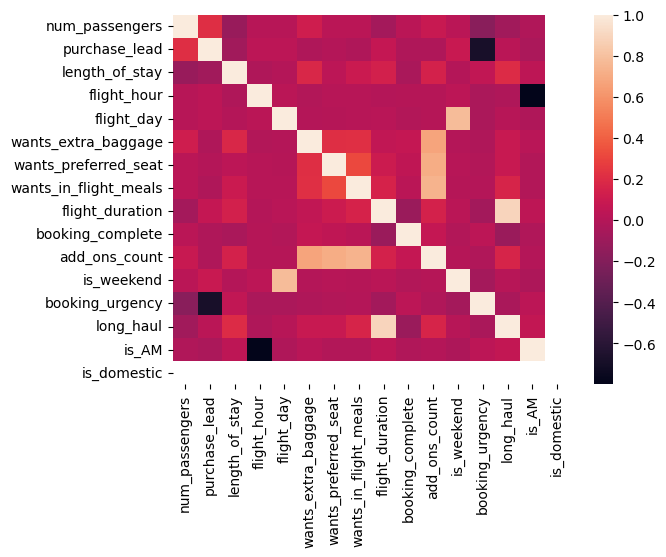

In [22]:
# Make a heatmap of the data 
_ = sns.heatmap(df.corr())
plt.show()

In [23]:
# Drop the column of is_domestic
try:
    df = df.drop(columns=['is_domestic'])
except KeyError:
    print("Column 'is_domestic' does not exist in the DataFrame.")

# Reorder the columns to have the num_passengers, purchase_lead, length_of_stay, flight_hour, add_ons_count, and flight_duration at the beginning
cols = ['num_passengers', 'purchase_lead', 'length_of_stay', 'flight_hour', 'add_ons_count', 'flight_duration'] + [col for col in df.columns if col not in ['num_passengers', 'purchase_lead', 'length_of_stay', 'flight_hour', 'add_ons_count', 'flight_duration', 'booking_complete']] + ['booking_complete']
df = df[cols]

print(df.head())

   num_passengers  purchase_lead  length_of_stay  flight_hour  add_ons_count  \
0               2            262              19            7              1   
1               1            112              20            3              0   
2               2            243              22           17              2   
3               1             96              31            4              1   
4               2             68              22           15              2   

   flight_duration sales_channel  trip_type  flight_day   route  ...  \
0             5.52      Internet  RoundTrip           6  AKLDEL  ...   
1             5.52      Internet  RoundTrip           6  AKLDEL  ...   
2             5.52      Internet  RoundTrip           3  AKLDEL  ...   
3             5.52      Internet  RoundTrip           6  AKLDEL  ...   
4             5.52      Internet  RoundTrip           3  AKLDEL  ...   

  wants_in_flight_meals  departure_city  arrival_city  is_weekend  \
0                

In [24]:
# Save the data to a new csv file for futher analysis
df.to_csv('../Data/customer_booking_v1.csv') 